In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [2]:
names_and_paths = [
    ("KL-Cov", "/ptmp/rfechner/out/exp17_more_rollouts/qwen2.5_7b__kl-cov/val_jsonl/60_rollouts.jsonl"),
    ("GRPO", "/ptmp/rfechner/out/exp17_more_rollouts/qwen2.5_7b__grpo/val_jsonl/60_rollouts.jsonl"),
    ('KL-Cov + Pass@k Training', '/ptmp/rfechner/out/exp17_more_rollouts/qwen2.5_7b__klcov_passk/val_jsonl/60_rollouts.jsonl'),
    ('Pass@k Training', '/ptmp/rfechner/out/exp17_more_rollouts/qwen2.5_7b__grpo-passk/val_jsonl/60_rollouts.jsonl')
]

In [3]:
from util import calculate_pass_at_k, qwen25_7b_lowvar_baselinepassk

In [4]:
basepassk = qwen25_7b_lowvar_baselinepassk(recompute=False, ks=2**np.arange(11))

In [6]:
dfs = {}
for name, file in names_and_paths:
    with open(file, 'r') as f:
        dfs[name] = pd.read_json(f, lines=True)

In [7]:
passk = {}
for mm, df in dfs.items():
    passk[mm] = calculate_pass_at_k(df, ks=2**np.arange(11))

In [8]:
passk['Base'] = basepassk

/tmp/ipykernel_102229/4259911644.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


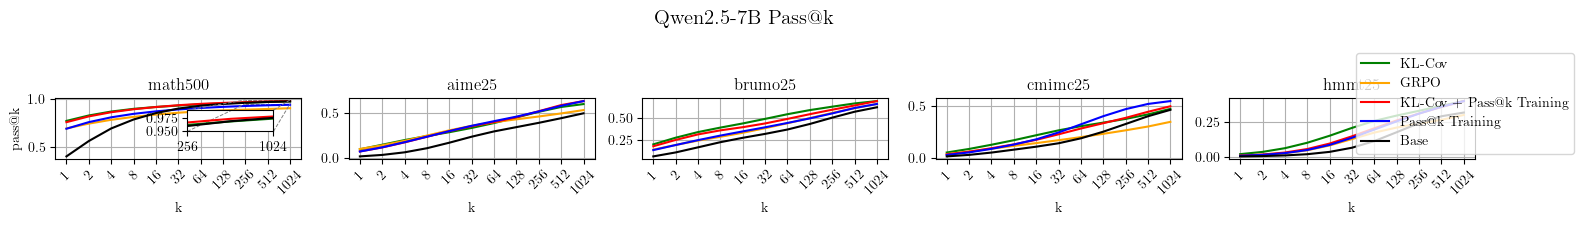

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

names = list(passk.keys())
colors  = {
    'KL-Cov': 'green',
    'Pass@k Training': 'blue',
    'KL-Cov + Pass@k Training': 'red',
    'GRPO' : 'orange',
    'Base' : 'black'
}
dataset_names = list(passk['KL-Cov'].keys())
fig, axes = plt.subplots(nrows=1, ncols=len(dataset_names), figsize=(3*len(dataset_names), 2))

# Sicherstellen, dass axes immer iterierbar ist (falls nur 1 Dataset existiert)
if len(dataset_names) == 1:
    axes = [axes]

for i, (ax, name) in enumerate(zip(axes, dataset_names)):
    for k, v in passk.items():
        vs = v[name].mean(axis=0)
        ax.plot(vs, label=k, color=colors[k])
    
    ax.set_title(name)
    ax.set_xticks(np.arange(len(vs)), 2**np.arange(len(vs)), rotation=45)
    ax.set_xlabel('k')
    ax.grid()
    # Zoom-In Effekt für den LETZTEN Plot
    if i == 0:
        # Inset erstellen
        ax_ins = inset_axes(ax, width="35%", height="35%", loc='lower right', borderpad=2)
        
        for k, v in passk.items():
            vs = v[name].mean(axis=0)
            ax_ins.plot(vs, color=colors[k])
        
        ax_ins.set_xlim(8, 10)
        ax_ins.set_ylim(0.95, 0.99)
        ax_ins.set_xticks([8, 10], [256, 1024])

        # ALLE VIER VERBINDUNGSLINIEN ZEICHNEN:
        # loc1 und loc2 definieren, welche Ecken verbunden werden.
        # Wir rufen es zweimal auf, um alle vier Ecken abzudecken:
        mark_inset(ax, ax_ins, loc1=1, loc2=4, fc="none", ec="0.5", ls="--", lw=0.7)
        mark_inset(ax, ax_ins, loc1=2, loc2=3, fc="none", ec="0.5", ls="--", lw=0.7)

axes[0].set_ylabel('pass@k')
plt.suptitle('Qwen2.5-7B Pass@k', y=1.1, fontsize=15)

# Legende fixieren
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.98, 0.92))
fig.savefig('/u/rfechner/verl/plots/outcome_based2/klcov_passk_comp.pdf', bbox_inches="tight")
plt.tight_layout()
plt.show()